In [1]:
import torch

import confidence.direct.logit_based
from confidence.direct.refiner import CurvatureRefiner
from confidence.model.single_pass import SinglePassConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
from confidence.utils import ModelInputWrapper
from utils.affine_transforms import AffineTransformation2D





C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\Lib\site-packages\libpyg.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\Lib\site-packages\torch_cluster\_grid_cuda.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
C:\Users\Lindner\PycharmProjects\experiments_rotation\.ven

In [2]:
from dataset.si_score import SIScoreDataset
from torchvision import models, transforms
dataset = SIScoreDataset(
    root="rotation",transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]),
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1519828].


Text(0.5, 1.0, 'Label: 407')

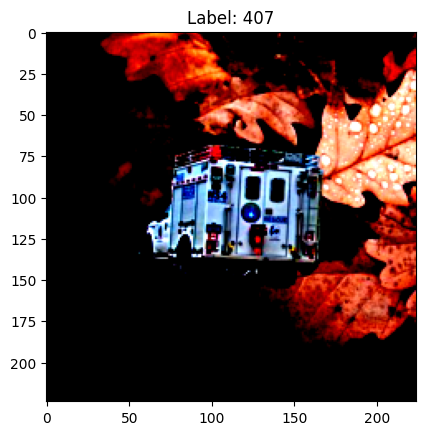

In [3]:
import matplotlib.pyplot as plt

plt.imshow(dataset[0][0].permute(1, 2, 0))
plt.title(f"Label: {dataset[0][1]}")

In [4]:
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
models.ViT_B_16_Weights.IMAGENET1K_V1.transforms

functools.partial(<class 'torchvision.transforms._presets.ImageClassification'>, crop_size=224)

In [7]:
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [8]:
from tqdm import tqdm
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(loader, desc="Evaluating ViT-B/16 on SI-SCORE")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

Evaluating ViT-B/16 on SI-SCORE:  15%|█▍        | 149/1009 [00:22<02:08,  6.70it/s, Running Acc=36.91%]


KeyboardInterrupt: 

In [9]:
#get size of the model
model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = model_size * 4 / 1024**2  # assuming float
print(f"Model size: {model_size_mb:.2f} MB")

Model size: 330.23 MB


In [10]:
inverse_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

Text(0.5, 1.0, 'Label: 407')

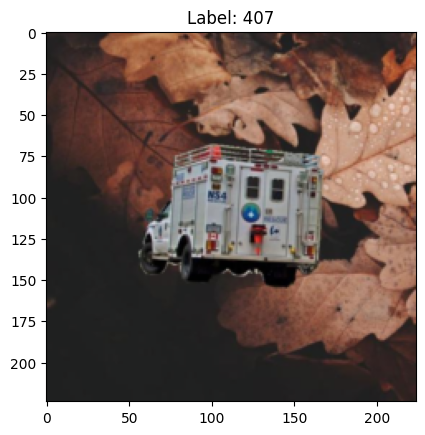

In [11]:
from matplotlib import pyplot as plt

plt.imshow(inverse_normalize(dataset[0][0]).permute(1, 2, 0))
plt.title(f"Label: {dataset[0][1]}")

In [12]:
dataloader_single = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

In [13]:
import math
import utils.affine_transforms

transforms = [utils.affine_transforms.AffineTransformation2D.ROTATION.value]
domains = [((-torch.pi,torch.pi),), (0.5, 1.5)]

In [14]:
import gc
gc.collect()

209

In [15]:
torch.cuda.empty_cache()

In [16]:
from its.search import InverseTransformationSearch

its = InverseTransformationSearch(
    model=model,
    transformation=transforms,
    domain=domains,
    n_samples=17,
    mc_steps=1,
    n_hypotheses=1,
)

from tqdm import tqdm

with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_single, desc="Evaluating ViT-B/16 on SI-SCORE")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = its.infer(images)[1][:,0]
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

Evaluating ViT-B/16 on SI-SCORE:   0%|          | 18/4036 [00:09<34:12,  1.96it/s, Running Acc=46.53%]


KeyboardInterrupt: 

In [23]:
from search.shgo import SHGO
di = SHGO(
    initial_samples=40,
    local_runs=1,
    local_max_steps=0,
)

In [24]:
import confidence.direct.logit_based

In [25]:
energy = confidence.direct.logit_based.EnergyConfidence()

In [26]:
from utils.transform_sequence import TransformSequence

transformation_sequence = TransformSequence(
    transformations=[
        utils.affine_transforms.AffineTransformation2D.ROTATION.value,
    ],
    domains=[(-torch.pi, torch.pi)],
    device=device,
)

In [27]:
from utils.transformation_problem import TransformationProblem

energy = confidence.direct.logit_based.EnergyConfidence(
)
from confidence.model.single_pass import SinglePassConfidence
conf = SinglePassConfidence(confidence=energy, model=model)
transformation_problem = TransformationProblem(
    transform_sequence= transformation_sequence,
    confidence_module=conf,max_batch_size=128)


In [28]:
from tqdm import tqdm
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_single, desc="Evaluating ViT-B/16 on SI-SCORE")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        p = di.optimize(
            transformation_problem=transformation_problem,
            x=images,
            y=None,
        )
        outputs = model(transformation_problem.transform(images, p[0]))
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

Evaluating ViT-B/16 on SI-SCORE:   0%|          | 12/4036 [00:07<41:45,  1.61it/s, Running Acc=34.38%]


KeyboardInterrupt: 

NameError: name 'InverseTransformationSearch' is not defined

In [29]:
from confidence.model.mc_droupout import MonteCarloDropoutConfidence
from torch import nn
import importlib
importlib.reload(confidence.direct.refiner)
from confidence.direct.refiner import CurvatureRefiner,GaussianSmoothingRefiner


class DualInputSequential(nn.Module):
    def __init__(self, *modules):
        super().__init__()
        self.modules_list = nn.ModuleList(modules)

    def forward(self, x, y=None):
        x = self.modules_list[0](x, y)
        for module in self.modules_list[1:]:
            x = module(x)
        return x

class DynamicUnflatten(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x, y=None):
        batch_size = x.size(0)
        true_batch = batch_size // self.dim
        x = x.view(true_batch, self.dim, *x.size()[1:])
        return x







energy2 = DualInputSequential(
    confidence.direct.logit_based.EnergyConfidence(
),
    DynamicUnflatten(dim=19),

    #GaussianSmoothingRefiner(
    #),
    #CurvatureRefiner(
    #),
    torch.nn.Flatten(0,-1)
)


conf2 = MonteCarloDropoutConfidence(
    confidence=energy2,
    model=model,
    samples=1,
    data_dims=3
)

its = InverseTransformationSearch(
    model=model,
    transformation=transforms,
    domain=domains,
    n_samples=17,
    mc_steps=1,
    n_hypotheses=1,
    confidence_module= conf2,
)




from tqdm import tqdm

with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_single, desc="Evaluating ViT-B/16 on SI-SCORE")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = its.infer(images)[1][:,0]
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

Evaluating ViT-B/16 on SI-SCORE:   0%|          | 16/4036 [00:08<34:17,  1.95it/s, Running Acc=46.09%]


KeyboardInterrupt: 

In [30]:
from its.search import gaussian_filter1d_channel_wise, gaussian_filter1d, curvature


def _estimate_confidence(z, channel_wise):
    """
    Estimate the confidence scores from the output of the model.
    :param z: The output of the model.
    :param gaussian_filter_channel_wise: Whether to apply a Gaussian filter channel-wise.
    :return: The estimated confidence scores.
    """
    # Apply Gaussian filter if specified
    energies = torch.log(torch.exp(z).sum(dim=-1))
    if channel_wise:
            # apply gaussian filter to each channel(hypthesis) separately
        energies = gaussian_filter1d_channel_wise(energies, sigma=2, radius=3, mode='replicate')
    else:
        energies = gaussian_filter1d(energies, sigma=2, radius=3, mode='replicate')
    return -curvature(energies.clone().detach().to(device=z.device))

def test(orbit):
        n_hypo=1
        z = model(orbit.flatten(end_dim=2))
        z = z.unflatten(0, (-1, n_hypo, 17+ 2*1))
        # squeeze away single orbit dim as len(T) = 1
        orbit = orbit.unflatten(0, (-1, n_hypo)).squeeze(dim=2)
        # T is a list of length 1
        # estimate the confidence scores (batch x n_hypotheses x n_samples)
        score = _estimate_confidence(z,True)
        return score

In [31]:
torch.cuda.empty_cache()

In [32]:
import torchvision
import torchvision.transforms.functional

dataset[0][0].unsqueeze(0)
#rotate it 19 times
ls = []
for i in range(19):
    res= torchvision.transforms.functional.rotate(dataset[0][0], (i-1) * 20+0.01, expand=False)
    ls.append(res)
    print(res.shape)
ls = torch.stack(ls, dim=0)




torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


In [33]:
conf2(ls.to(device))[0].detach().cpu().numpy()

array([8.357272 , 8.313628 , 8.269048 , 7.5746922, 8.178483 , 7.9219756,
       8.304099 , 8.229177 , 7.6532297, 7.9030924, 8.966247 , 7.580874 ,
       7.576825 , 7.6096044, 7.6437654, 8.065271 , 7.828765 , 7.7258034,
       8.357272 ], dtype=float32)

In [34]:
test(ls.unsqueeze(0).unsqueeze(0).to(device)).detach().cpu().numpy()

array([[[ 0.01132536,  0.00300169, -0.02123618, -0.02961636,
         -0.01273346, -0.02036715, -0.01650214,  0.02239609,
          0.03245521,  0.03233111,  0.02062833, -0.01018381,
         -0.01720488, -0.04220068, -0.07098818, -0.04112935,
         -0.00990307, -0.00522351, -0.00234056]]], dtype=float32)

In [35]:
import os
#authenticate with huggingface
from huggingface_hub import login
token = os.getenv("HUGGINGFACE_TOKEN")
login(token)

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
from datasets import load_dataset
from tqdm import tqdm
from PIL import Image
import statistics
import os

# Parameters
MIN_IMAGES = 50
MAX_IMAGES = 100
SAVE_DIR = "imagenet_subset"

# Load ImageNet-1k in streaming mode
ds = load_dataset("imagenet-1k", split="train", streaming=True, trust_remote_code=True)

# Track counts
counts = {i: 0 for i in range(1000)}  # one entry per class

# Make root save directory
os.makedirs(SAVE_DIR, exist_ok=True)
#check if the directory is empty
if not os.listdir(SAVE_DIR):
    # Wrap dataset in tqdm
    pbar = tqdm(ds, desc="Filtering dataset", unit="samples")
    for i, example in enumerate(pbar):
        label = example["label"]

        # Skip if this class already has enough
        if counts[label] >= MAX_IMAGES:
            continue

        # Save image to its class folder
        class_dir = os.path.join(SAVE_DIR, str(label))
        os.makedirs(class_dir, exist_ok=True)

        filename = os.path.join(class_dir, f"{counts[label]:04d}.jpg")


        img = example["image"].convert("RGB")
        img.save(filename, "JPEG")
        counts[label] += 1

        # Update tqdm description every 2000 samples

        nonzero = [c for c in counts.values() if c > 0]
        lowest = min(counts.values())
        avg = statistics.mean(nonzero) if nonzero else 0
        pbar.set_description(f"Lowest={lowest}, Avg={avg:.2f}")

        # Stop when all classes have at least MIN_IMAGES
        if all(c >= MIN_IMAGES for c in counts.values()):
            pbar.set_description(f"✅ Done: Lowest={MIN_IMAGES}, Avg={statistics.mean(counts.values()):.2f}")
            break

    pbar.close()
    print("Done! Images saved in:", SAVE_DIR)


In [37]:
from dataset.si_score import ImageNetSubset
from torchvision import models, transforms
dataset_imagenet = ImageNetSubset(
    root="imagenet_subset",   transform=models.ViT_B_16_Weights.IMAGENET1K_V1.transforms())


In [38]:
len(dataset_imagenet)

95476

In [39]:
dataset_imagenet[0]

(tensor([[[-1.0733, -1.2959, -1.5185,  ..., -1.8439, -1.7583, -1.9295],
          [-1.6727, -1.6898, -1.6555,  ..., -1.8268, -1.7412, -1.8439],
          [-1.6384, -1.5014, -1.5699,  ..., -1.8097, -1.7240, -1.7925],
          ...,
          [-1.7925, -1.8268, -1.8097,  ..., -1.5014, -1.4843, -1.5014],
          [-1.8097, -1.8610, -1.8439,  ..., -1.5185, -1.5014, -1.4500],
          [-1.7925, -1.8268, -1.7754,  ..., -1.4843, -1.4843, -1.4500]],
 
         [[-0.8978, -1.1253, -1.3529,  ..., -1.6331, -1.5455, -1.7206],
          [-1.4930, -1.5280, -1.4930,  ..., -1.6155, -1.5280, -1.6331],
          [-1.4580, -1.3354, -1.4055,  ..., -1.5980, -1.5105, -1.5805],
          ...,
          [-1.7906, -1.8256, -1.7381,  ..., -1.4755, -1.4580, -1.4755],
          [-1.8081, -1.8606, -1.7731,  ..., -1.4930, -1.4930, -1.4405],
          [-1.7906, -1.8081, -1.7556,  ..., -1.5105, -1.5105, -1.4755]],
 
         [[-0.6715, -0.8807, -1.1247,  ..., -1.5256, -1.4210, -1.6127],
          [-1.2990, -1.3164,

In [40]:
list(model.named_modules())

[('',
  VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): LayerNorm((768,), e

In [41]:
from confidence.utils import ModelInputWrapper
dual_ouput_model = ModelInputWrapper(
    model,
    target_layer_name="heads",
)


In [42]:
embeddings=[]
dataloader_imagenet = torch.utils.data.DataLoader(
    dataset_imagenet,
    batch_size=128,
    shuffle=True,
    num_workers=4,
)
classes = []
with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_imagenet, desc="Extracting embeddings")
    for images, labels in pbar:
        images = images.to(device)
        res = dual_ouput_model(images)
        emb = res[0].detach().cpu()
        #calculate accuracy
        preds = res[1].argmax(dim=1).cpu()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})
        #only add correct embeddings
        emb_correct = emb[preds == labels]
        embeddings.append(emb_correct)
        classes.append(labels[preds == labels].cpu())




with torch.no_grad():
    embeddings = torch.cat(embeddings, dim=0)
    classes = torch.cat(classes, dim=0)

Extracting embeddings: 100%|██████████| 746/746 [05:07<00:00,  2.43it/s, Running Acc=93.72%]


In [47]:

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

nn_pytorch = PerClassKNNConfidence(metric="cosine",k=2)
nn_pytorch.fit(embeddings,classes)
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.002)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transformation_sequence,consolidate_method="consolidate_simple",max_batch_size=128)

In [48]:
from tqdm import tqdm
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_single, desc="Evaluating ViT-B/16 on SI-SCORE")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        p = di.optimize(
            transformation_problem=problem_nn_pytorch,
            x=images,
            y=None,
        )
        outputs = model(transformation_problem.transform(images, p[0]))
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

Evaluating ViT-B/16 on SI-SCORE:   4%|▍         | 165/4036 [01:36<37:33,  1.72it/s, Running Acc=55.00%]


KeyboardInterrupt: 

In [46]:
from confidence.unsupervised.classic.VIM import ViMTorchConfidence

vim = ViMTorchConfidence(model,n_dim=368)
vim.fit(embeddings.cuda())
conf_split = SplitConfidence(vim,EnergyConfidence(), mult=False,b=0.0)
conf_mod_vim = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_vim = TransformationProblem(
    transform_sequence=transformation_sequence,
    confidence_module=conf_mod_vim,
    consolidate_method="consolidate_simple",
    max_batch_size=128
)



In [47]:
from tqdm import tqdm
model.eval()
with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_single, desc="Evaluating ViT-B/16 on SI-SCORE")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        p = di.optimize(
            transformation_problem=problem_vim,
            x=images,
            y=None,
        )
        outputs = model(transformation_problem.transform(images, p[0]))
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

Evaluating ViT-B/16 on SI-SCORE:   1%|          | 34/4036 [00:34<1:06:47,  1.00s/it, Running Acc=49.26%]


KeyboardInterrupt: 

In [22]:
its3= InverseTransformationSearch(
    model=model,
    transformation=transforms,
    domain=domains,
    n_samples=40,
    mc_steps=1,
    n_hypotheses=1,
    confidence_module=conf_mod_nn_pytorch,
)
from tqdm import tqdm
with torch.no_grad():
    correct, total = 0, 0
    pbar = tqdm(dataloader_single, desc="Evaluating ViT-B/16 on SI-SCORE with KNN Confidence")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = its3.infer(images)[1][:,0]
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100.0 * correct / total
        pbar.set_postfix({"Running Acc": f"{acc:.2f}%"})

NameError: name 'conf_mod_nn_pytorch' is not defined

In [95]:
gc.collect()
torch.cuda.empty_cache()